In [1]:
import sys
sys.path.insert(0, '/user/bnc2119/drd')
import numpy as np, pandas as pd
import torch
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib as mpl
from utils import *
from src.drd import AutoEncoder
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import fetch_openml
%load_ext autoreload
%autoreload 2

/user/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-21 09:52:32.865957: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766328752.877756  123838 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766328752.881626  123838 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766328752.891616  123838 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once

In [2]:
PATH_PREFIX = "/shared/share_mala/irchang/drd"
# loading AE
def load_trained_ae(ckpt_path, input_dim, hidden_dims, latent_dim=2, batchnorm=False):
    import sys, os
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, "w")
    model = AutoEncoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        activation=torch.nn.SELU,            # match training!
        bottleneck_activation=None,
        use_batchnorm = batchnorm
    )
    sys.stdout = old_stdout

    sd = torch.load(ckpt_path, map_location="cpu")

    # unwrap to the real state dict
    if isinstance(sd, dict) and "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]
    elif isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]

    # remove DDP prefixes if any
    sd = {k.replace("module.", ""): v for k, v in sd.items()}

    # load STRICTLY so we fail fast if something doesn’t match
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f"loaded params: {len(sd)} | missing={len(missing)} | unexpected={len(unexpected)}")
    if missing or unexpected:
        print("⚠️ Check architecture/keys. Example missing:", missing[:3], "unexpected:", unexpected[:3])

    model.eval()
    return model

### MNIST

In [54]:
mnist_tsne_res_dict = []
X, X_test, y, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for perp in [    5,    11,    27,    62,   146,   341,   793,  1846,  4297]:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"embeddings/mnist_tsne_{perp}_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/tsne2_{perp}_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[1000, 1000, 1000, 1000, 1000],
                latent_dim=2)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            train_recon = np.mean((student_recon.detach().numpy() - X)**2)
            mnist_tsne_res_dict.append({"perplexity": perp, "recon_loss": train_recon, "split": "Train", "seed": s})

            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            mnist_tsne_res_dict.append({"perplexity": perp, "recon_loss": test_recon, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {perp} seed {s} due to distillation loss {train_distill}")

loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded par

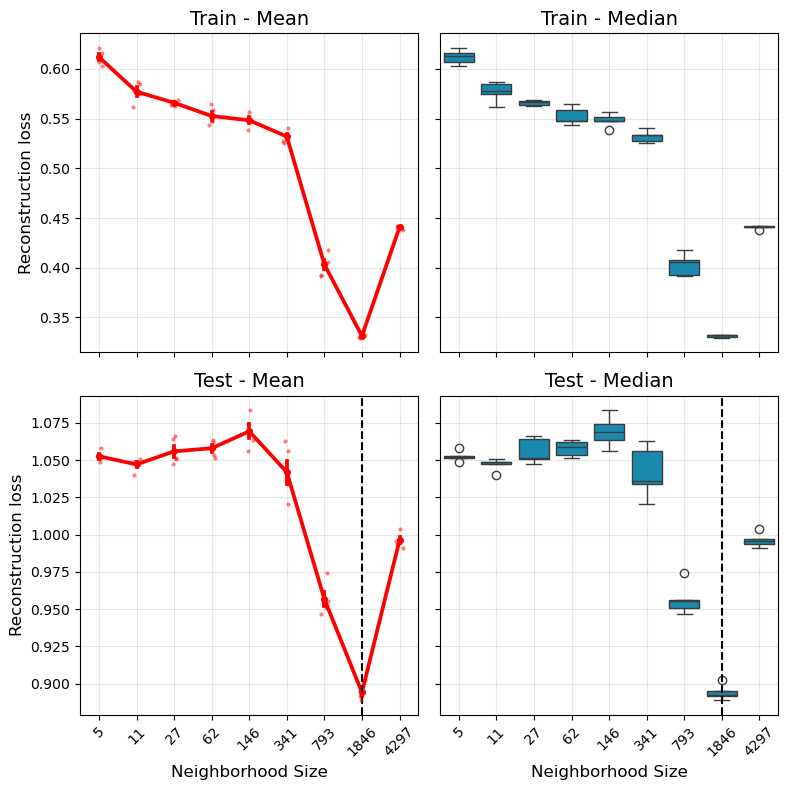

In [55]:
analysis = pd.DataFrame(mnist_tsne_res_dict)
analysis.sort_values(by='perplexity', inplace=True)
tsne_argmin_mean = analysis[analysis.split == "Test"].groupby('perplexity')['recon_loss'].mean().idxmin()
tsne_argmin_median = analysis[analysis.split == "Test"].groupby('perplexity')['recon_loss'].median().idxmin()
unique_neighbors = sorted(analysis['perplexity'].unique())
pos_mean = unique_neighbors.index(tsne_argmin_mean)
pos_median = unique_neighbors.index(tsne_argmin_median)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), sharey='row', sharex=True)
for i, split in enumerate(['Train', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="perplexity", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="perplexity", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="perplexity", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Neighborhood Size", fontsize=12)
        ax.set_ylabel("Reconstruction loss", fontsize=12)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
    if split == "Test":
        ax_point.axvline(x=pos_mean, ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

plt.tight_layout()
plt.show()

In [56]:
mnist_umap_res_dict = []
X, X_test, y, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"embeddings/mnist_umap_{n}_0.1_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/umap2_{n}_0.1_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[1000, 1000, 1000, 1000, 1000],
                latent_dim=2)
    
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            train_recon = np.mean((student_recon.detach().numpy() - X)**2)
            mnist_umap_res_dict.append({"n_neighbors": n, "recon_loss": train_recon, "split": "Train", "seed": s})

            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            mnist_umap_res_dict.append({"n_neighbors": n, "recon_loss": test_recon, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {n} seed {s} due to distillation loss {train_distill}")

loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded par

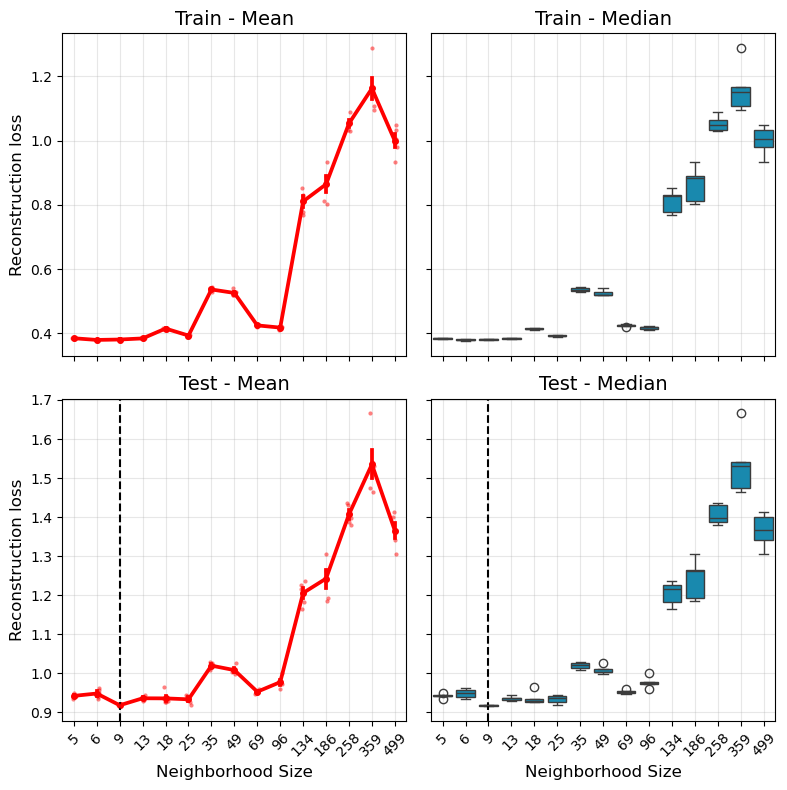

In [57]:
analysis = pd.DataFrame(mnist_umap_res_dict)
analysis.sort_values(by='n_neighbors', inplace=True)
umap_argmin_mean = analysis[analysis.split == "Test"].groupby('n_neighbors')['recon_loss'].mean().idxmin()
umap_argmin_median = analysis[analysis.split == "Test"].groupby('n_neighbors')['recon_loss'].median().idxmin()

unique_neighbors = sorted(analysis['n_neighbors'].unique())
pos_mean = unique_neighbors.index(umap_argmin_mean)
pos_median = unique_neighbors.index(umap_argmin_median)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), sharey='row', sharex=True)

for i, split in enumerate(['Train', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="n_neighbors", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="n_neighbors", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="n_neighbors", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Neighborhood Size", fontsize=12)
        ax.set_ylabel("Reconstruction loss", fontsize=12)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
    if split == "Test":
        ax_point.axvline(x=pos_mean, ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

plt.tight_layout()
plt.show()

In [58]:
mnist_spectral_res_dict = []
X, X_test, y, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"embeddings/mnist_spectral_{n}_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/spectral2_{n}_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[1000, 1000, 1000, 1000, 1000],
                latent_dim=2)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            train_recon = np.mean((student_recon.detach().numpy() - X)**2)
            mnist_spectral_res_dict.append({"n_neighbors": n, "recon_loss": train_recon, "split": "Train", "seed": s})

            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            mnist_spectral_res_dict.append({"n_neighbors": n, "recon_loss": test_recon, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {n} seed {s} due to distillation loss {train_distill}")

loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded par

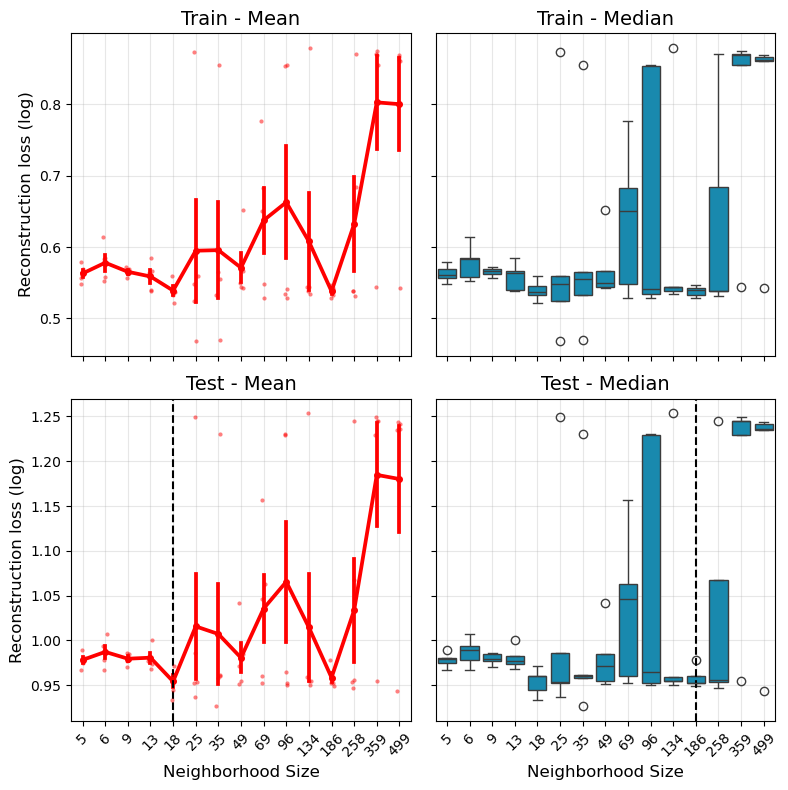

In [59]:
analysis = pd.DataFrame(mnist_spectral_res_dict)
analysis.sort_values(by='n_neighbors',inplace=True)
spectral_argmin_mean = analysis[analysis.split == "Test"].groupby('n_neighbors')['recon_loss'].mean().idxmin()
spectral_argmin_median = analysis[analysis.split == "Test"].groupby('n_neighbors')['recon_loss'].median().idxmin()

unique_neighbors = sorted(analysis['n_neighbors'].unique())
pos_mean = unique_neighbors.index(spectral_argmin_mean)
pos_median = unique_neighbors.index(spectral_argmin_median)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), sharey='row', sharex=True)

for i, split in enumerate(['Train', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="n_neighbors", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="n_neighbors", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="n_neighbors", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        # if split == "Test": ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Neighborhood Size", fontsize=12)
        ax.set_ylabel("Reconstruction loss (log)", fontsize=12)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
    if split == "Test":
        ax_point.axvline(x=pos_mean, ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

plt.tight_layout()
plt.show()


In [60]:
mnist_pca_res_dict = []
X, X_test, y, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
for s in range(5):
    student_pca = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/pca2_{s}_ckpts/final.pt",
            input_dim=784,
            hidden_dims=[1000, 1000, 1000, 1000, 1000],
            latent_dim=2)
    
    student_recon, student_embed = student_pca(torch.tensor(X, dtype=torch.float32))
    train_recon = np.mean((student_recon.detach().numpy() - X)**2)
    mnist_pca_res_dict.append({"recon_loss": train_recon, "split": "Train", "seed": s})

    x_test_recon, _ = student_pca(torch.tensor(X_test, dtype=torch.float32))
    test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
    mnist_pca_res_dict.append({"recon_loss": test_recon, "split": "Test", "seed": s})

loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0
loaded params: 24 | missing=0 | unexpected=0


In [61]:
tsne_analysis = pd.DataFrame(mnist_tsne_res_dict)
tsne_analysis = tsne_analysis.loc[(tsne_analysis.split=='Test'),:]
tsne_analysis_agg = tsne_analysis.loc[:, ['perplexity','recon_loss']].groupby('perplexity').agg('mean').reset_index()
umap_analysis = pd.DataFrame(mnist_umap_res_dict)
umap_analysis = umap_analysis.loc[(umap_analysis.split=='Test'), :]
umap_analysis_agg = umap_analysis.loc[:, ['n_neighbors','recon_loss']].groupby('n_neighbors').agg('mean').reset_index()
spectral_analysis = pd.DataFrame(mnist_spectral_res_dict)
spectral_analysis = spectral_analysis.loc[(spectral_analysis.split=='Test'), :]
spectral_analysis_agg = spectral_analysis.loc[:, ['n_neighbors','recon_loss']].groupby('n_neighbors').agg('mean').reset_index()
pca_analysis = pd.DataFrame(mnist_pca_res_dict)
pca_analysis = pca_analysis.loc[(pca_analysis.split=='Test'), :]

In [62]:
tsne_best = tsne_analysis.loc[tsne_analysis.perplexity == tsne_argmin_mean, ['recon_loss', 'seed']]
tsne_best['method'] = f'TSNE(perplexity={tsne_argmin_mean})'
umap_best = umap_analysis.loc[umap_analysis.n_neighbors == umap_argmin_mean, ['recon_loss', 'seed']]
umap_best['method'] = f'UMAP(n_neighbors={umap_argmin_mean})'
spectral_best = spectral_analysis.loc[spectral_analysis.n_neighbors == spectral_argmin_mean, ['recon_loss', 'seed']]
spectral_best['method'] = f'Spectral(n_neighbors={spectral_argmin_mean})'
pca_best = pca_analysis[['recon_loss', 'seed']]
pca_best['method'] = 'PCA'
teachers = pd.concat([tsne_best, umap_best, spectral_best, pca_best])

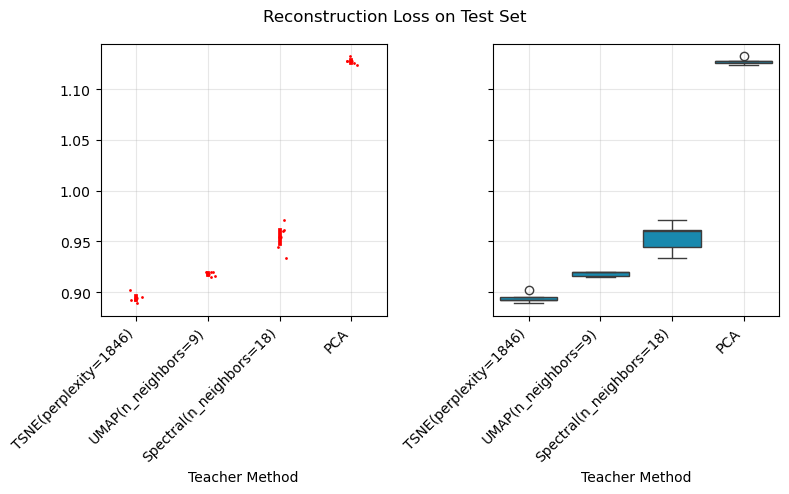

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(8,5), sharey=True)
sns.pointplot(data=teachers, x = 'method', y='recon_loss', linestyles='none', markersize=1, errorbar='se', ax = axes[0], color='red')
sns.stripplot(data=teachers, x = 'method', y='recon_loss', size=2, ax = axes[0], color='red')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel("")
axes[0].set_xlabel("Teacher Method")

sns.boxplot(data=teachers, x = 'method', y='recon_loss', ax = axes[1], color='#0096C7')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel("")

axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel("Teacher Method")
fig.suptitle("Reconstruction Loss on Test Set")

plt.tight_layout()

### Hydra

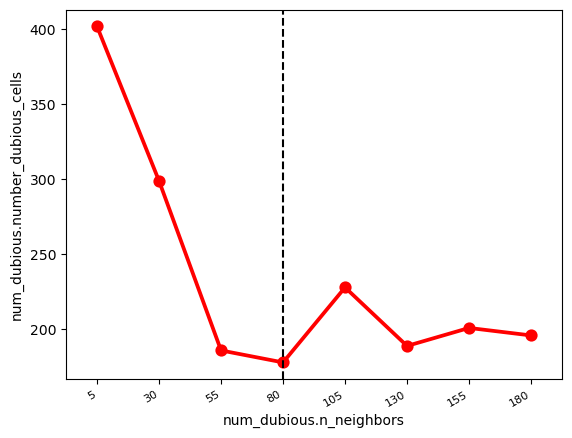

In [17]:
scdeed_analysis = pd.read_csv(Path(PATH_PREFIX) / 'tmp/hydra_scdeed_umap.csv', index_col=0)
scdeed_analysis = scdeed_analysis[scdeed_analysis['num_dubious.min.dist'] == 0.1]
umap_argmin = scdeed_analysis['num_dubious.number_dubious_cells'].idxmin()
argmin_position = scdeed_analysis.index.tolist().index(umap_argmin)
sns.pointplot(data=scdeed_analysis, x='num_dubious.n_neighbors', y='num_dubious.number_dubious_cells', color='red')
plt.xticks(rotation=30, fontsize=8, ha='right')
plt.axvline(x = argmin_position, ls = '--', c ='black')
plt.show()

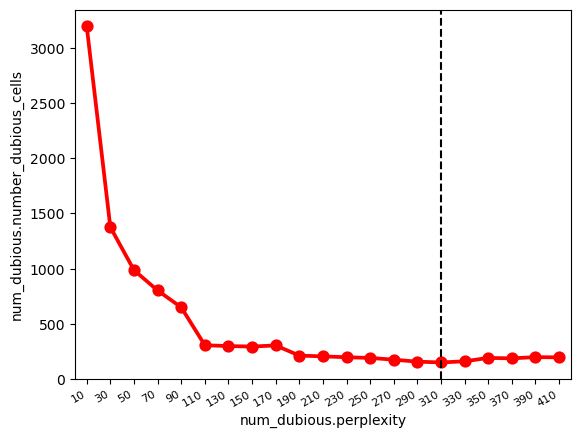

In [19]:
scdeed_analysis = pd.read_csv(Path(PATH_PREFIX) / 'tmp/hydra_scdeed_tsne.csv', index_col=0)
tsne_argmin = scdeed_analysis['num_dubious.number_dubious_cells'].idxmin()
argmin_position = scdeed_analysis.index.tolist().index(tsne_argmin)
sns.pointplot(data=scdeed_analysis, x='num_dubious.perplexity', y='num_dubious.number_dubious_cells', c='r')
plt.axvline(x = argmin_position, ls = '--', c ='black')
plt.xticks(rotation=30, fontsize=8, ha='right');

In [33]:
dubious_arr = scdeed_analysis.loc[tsne_argmin, 'full_results.dubious_cells'].split(',')
dubious_df = pd.DataFrame([], index = dubious_arr)
dubious_df['labels'] = 'dubious'
trustworthy_arr = scdeed_analysis.loc[tsne_argmin, 'full_results.trustworthy_cells'].split(',')
trustworthy_df = pd.DataFrame([], index = trustworthy_arr)
trustworthy_df['labels'] = 'trustworthy'
inter_arr = scdeed_analysis.loc[tsne_argmin, 'full_results.intermediate_cells'].split(',')
inter_df = pd.DataFrame([], index = inter_arr)
inter_df['labels'] = 'intermediate'
all_df = pd.concat([dubious_df, trustworthy_df, inter_df]).to_csv(Path(PATH_PREFIX) / 'tmp/hydra_scdeed_tsne_labels.csv')

In [4]:
hydra_tsne_res_dict = []
X, X_test, y, y_test = load_and_split("hydra", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for perp in np.unique(np.logspace(np.log10(5), np.log10(5000), 10).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"embeddings/hydra_tsne_{perp}_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/hydra/tsne2_{perp}_{s}_ckpts/final.pt",
                input_dim=500,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2, batchnorm=True)
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)

        if train_distill < 1e-5:
            train_recon = np.mean((student_recon.detach().numpy() - X)**2)
            hydra_tsne_res_dict.append({"perplexity": perp, "recon_loss": train_recon, "split": "Train", "seed": s})

            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            hydra_tsne_res_dict.append({"perplexity": perp, "recon_loss": test_recon, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {perp} seed {s} due to distillation loss {train_distill}")

loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded par

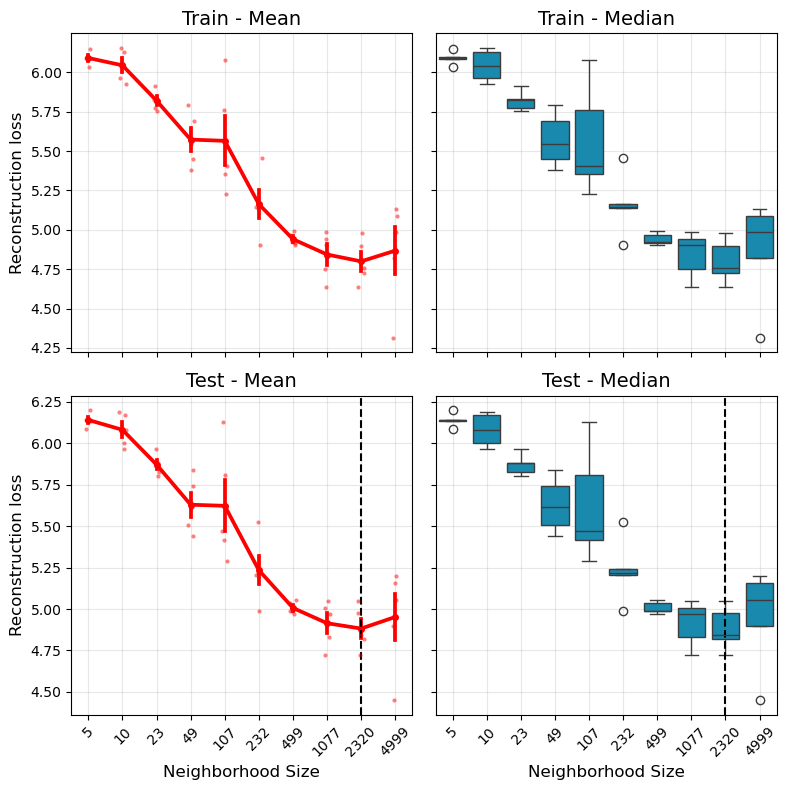

In [46]:
analysis = pd.DataFrame(hydra_tsne_res_dict)
analysis.sort_values(by='perplexity', inplace=True)
tsne_argmin_mean = analysis[analysis.split == "Test"].groupby('perplexity')['recon_loss'].mean().idxmin()
tsne_argmin_median = analysis[analysis.split == "Test"].groupby('perplexity')['recon_loss'].median().idxmin()
unique_neighbors = sorted(analysis['perplexity'].unique())
pos_mean = unique_neighbors.index(tsne_argmin_mean)
pos_median = unique_neighbors.index(tsne_argmin_median)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), sharey='row', sharex=True)
for i, split in enumerate(['Train', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="perplexity", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="perplexity", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="perplexity", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Neighborhood Size", fontsize=12)
        ax.set_ylabel("Reconstruction loss", fontsize=12)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
    if split == "Test":
        ax_point.axvline(x=pos_mean, ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

plt.tight_layout()
plt.show()

In [6]:
hydra_umap_res_dict = []
X, X_test, y, y_test = load_and_split("hydra", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(2000), 10).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"embeddings/hydra_umap_{n}_0.1_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/hydra/umap2_{n}_0.1_{s}_ckpts/final.pt",
                input_dim=500,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2,
                batchnorm=True)
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)

        if train_distill < 1e-5:
            train_recon = np.mean((student_recon.detach().numpy() - X)**2)
            hydra_umap_res_dict.append({"n_neighbors": n, "recon_loss": train_recon, "split": "Train", "seed": s})

            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon= np.mean((x_test_recon.detach().numpy() - X_test)**2)
            hydra_umap_res_dict.append({"n_neighbors": n, "recon_loss": test_recon, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {n} seed {s} due to distillation loss {train_distill}")

loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded par

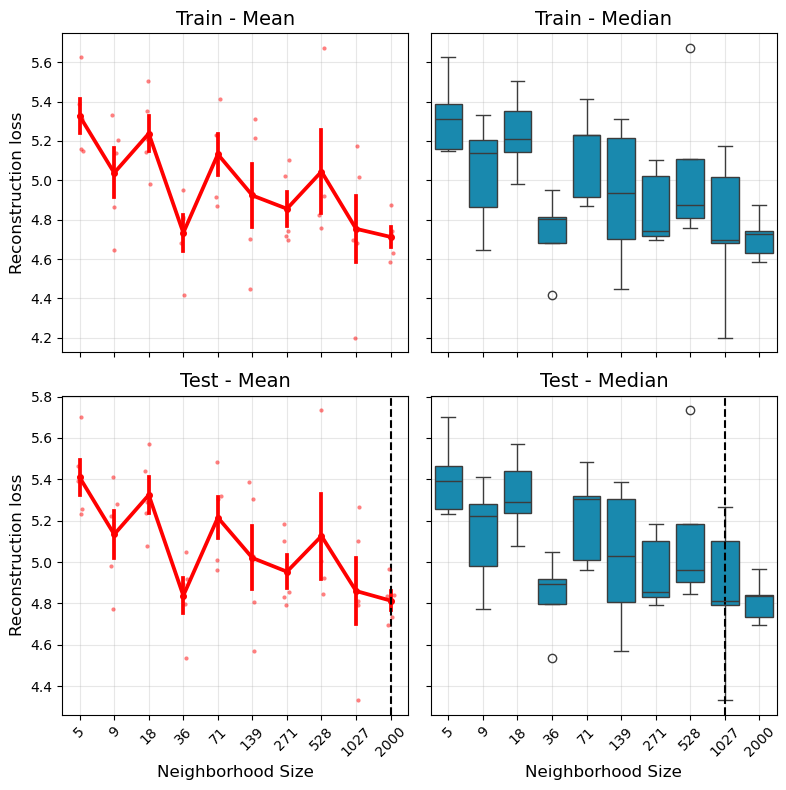

In [47]:
analysis = pd.DataFrame(hydra_umap_res_dict)
analysis.sort_values(by='n_neighbors', inplace=True)
umap_argmin_mean = analysis[analysis.split == "Test"].groupby('n_neighbors')['recon_loss'].mean().idxmin()
umap_argmin_median = analysis[analysis.split == "Test"].groupby('n_neighbors')['recon_loss'].median().idxmin()

unique_neighbors = sorted(analysis['n_neighbors'].unique())
pos_mean = unique_neighbors.index(umap_argmin_mean)
pos_median = unique_neighbors.index(umap_argmin_median)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), sharey='row', sharex=True)

for i, split in enumerate(['Train', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="n_neighbors", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="n_neighbors", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="n_neighbors", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Neighborhood Size", fontsize=12)
        ax.set_ylabel("Reconstruction loss", fontsize=12)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
    if split == "Test":
        ax_point.axvline(x=pos_mean, ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

plt.tight_layout()
plt.show()

In [9]:
hydra_spectral_res_dict = []
X, X_test, y, y_test = load_and_split("hydra", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(200), 15).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"embeddings/hydra_spectral_{n}_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/hydra/spectral2_{n}_{s}_ckpts/final.pt",
                input_dim=500,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2, batchnorm=True)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            train_recon = np.mean((student_recon.detach().numpy() - X)**2)
            hydra_spectral_res_dict.append({"n_neighbors": n, "recon_loss": train_recon, "split": "Train", "seed": s})

            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            hydra_spectral_res_dict.append({"n_neighbors": n, "recon_loss": test_recon, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {n} seed {s} due to distillation loss {train_distill}")

loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded par

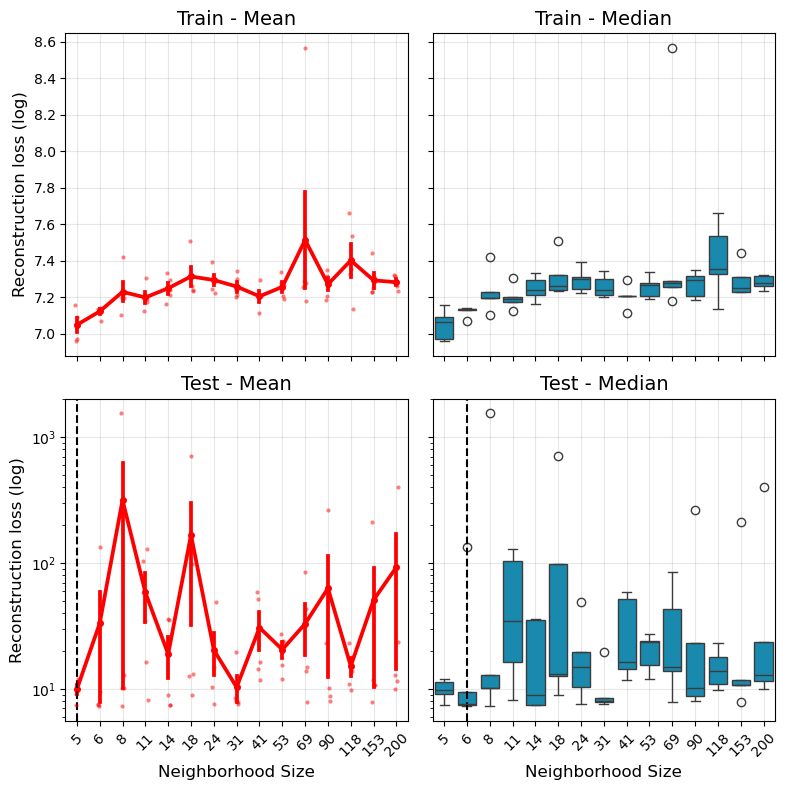

In [48]:
analysis = pd.DataFrame(hydra_spectral_res_dict)
analysis.sort_values(by='n_neighbors', inplace=True)
spectral_argmin_mean = analysis[analysis.split == "Test"].groupby('n_neighbors')['recon_loss'].mean().idxmin()
spectral_argmin_median = analysis[analysis.split == "Test"].groupby('n_neighbors')['recon_loss'].median().idxmin()

unique_neighbors = sorted(analysis['n_neighbors'].unique())
pos_mean = unique_neighbors.index(spectral_argmin_mean)
pos_median = unique_neighbors.index(spectral_argmin_median)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), sharey='row', sharex=True)

for i, split in enumerate(['Train', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="n_neighbors", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="n_neighbors", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="n_neighbors", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Neighborhood Size", fontsize=12)
        ax.set_ylabel("Reconstruction loss (log)", fontsize=12)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
    if split == "Test":
        ax_point.set_yscale('log')
        ax_box.set_yscale('log')
        ax_point.axvline(x=pos_mean, ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

plt.tight_layout()
plt.show()


In [49]:
hydra_pca_res_dict = []
X, X_test, y, y_test = load_and_split("hydra", test_size=0.2, seed=0, labels=True)
for s in range(5):
    student_pca = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/hydra/pca2_{s}_ckpts/final.pt",
                                  input_dim=500,
                                  hidden_dims=[309, 1792, 1792, 1792],
                                  latent_dim=2, batchnorm=True)
    
    student_recon_pca, student_embed_pca = student_pca(torch.tensor(X, dtype=torch.float32))
    train_recon = np.mean((student_recon_pca.detach().numpy() - X)**2)
    hydra_pca_res_dict.append({"recon_loss": train_recon, "split": "Train", "seed": s})

    x_test_recon, _ = student_pca(torch.tensor(X_test, dtype=torch.float32))
    test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
    hydra_pca_res_dict.append({"recon_loss": test_recon, "split": "Test", "seed": s})

loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


In [50]:
tsne_analysis = pd.DataFrame(hydra_tsne_res_dict)
tsne_analysis = tsne_analysis.loc[(tsne_analysis.split=='Test'),:]
tsne_analysis_agg = tsne_analysis.loc[:, ['perplexity','recon_loss']].groupby('perplexity').agg('mean').reset_index()
umap_analysis = pd.DataFrame(hydra_umap_res_dict)
umap_analysis = umap_analysis.loc[(umap_analysis.split=='Test'), :]
umap_analysis_agg = umap_analysis.loc[:, ['n_neighbors','recon_loss']].groupby('n_neighbors').agg('mean').reset_index()
spectral_analysis = pd.DataFrame(hydra_spectral_res_dict)
spectral_analysis = spectral_analysis.loc[(spectral_analysis.split=='Test'), :]
spectral_analysis_agg = spectral_analysis.loc[:, ['n_neighbors','recon_loss']].groupby('n_neighbors').agg('mean').reset_index()

pca_analysis = pd.DataFrame(hydra_pca_res_dict)
pca_analysis = pca_analysis.loc[(pca_analysis.split=='Test'), :]

tsne_best = tsne_analysis.loc[tsne_analysis.perplexity == tsne_argmin_mean, ['recon_loss', 'seed']]
tsne_best['method'] = f'TSNE(perplexity={tsne_argmin_mean})'
umap_best = umap_analysis.loc[umap_analysis.n_neighbors == umap_argmin_mean, ['recon_loss', 'seed']]
umap_best['method'] = f'UMAP(n_neighbors={umap_argmin_mean})'
spectral_best = spectral_analysis.loc[spectral_analysis.n_neighbors == spectral_argmin_mean, ['recon_loss', 'seed']]
spectral_best['method'] = f'Spectral(n_neighbors={spectral_argmin_mean})'
pca_best = pca_analysis[['recon_loss', 'seed']]
pca_best['method'] = 'PCA'
teachers = pd.concat([tsne_best, umap_best, spectral_best, pca_best])

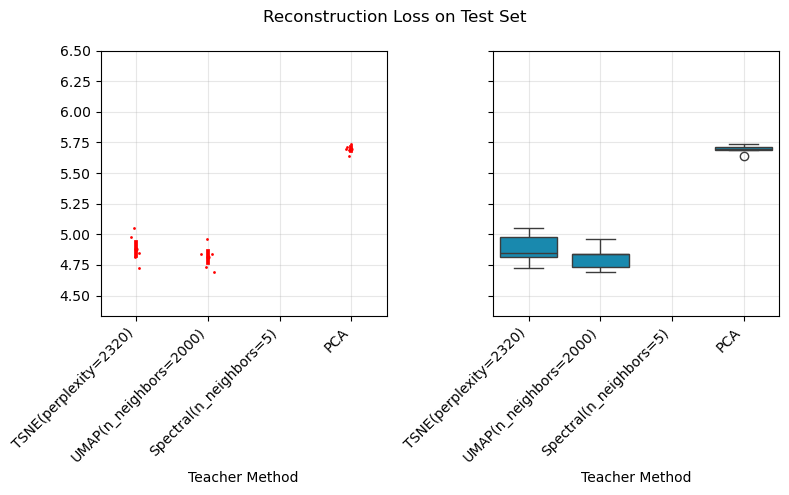

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(8,5), sharey=True)
sns.pointplot(data=teachers, x = 'method', y='recon_loss', linestyles='none', markersize=1, errorbar='se', ax = axes[0], color='red')
sns.stripplot(data=teachers, x = 'method', y='recon_loss', size=2, ax = axes[0], color='red')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel("")
axes[0].set_xlabel("Teacher Method")
axes[0].set_ylim(top=6.5)

sns.boxplot(data=teachers, x = 'method', y='recon_loss', ax = axes[1], color='#0096C7')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel("")

axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel("Teacher Method")
fig.suptitle("Reconstruction Loss on Test Set")

plt.tight_layout()

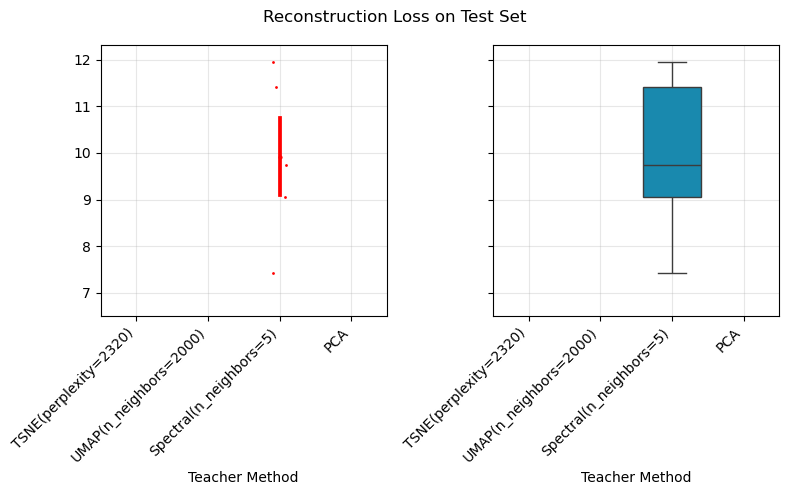

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(8,5), sharey=True)
sns.pointplot(data=teachers, x = 'method', y='recon_loss', linestyles='none', markersize=1, errorbar='se', ax = axes[0], color='red')
sns.stripplot(data=teachers, x = 'method', y='recon_loss', size=2, ax = axes[0], color='red')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel("")
axes[0].set_xlabel("Teacher Method")
axes[0].set_ylim(bottom=6.5)

sns.boxplot(data=teachers, x = 'method', y='recon_loss', ax = axes[1], color='#0096C7')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel("")

axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel("Teacher Method")
fig.suptitle("Reconstruction Loss on Test Set")

plt.tight_layout()

### Cortical

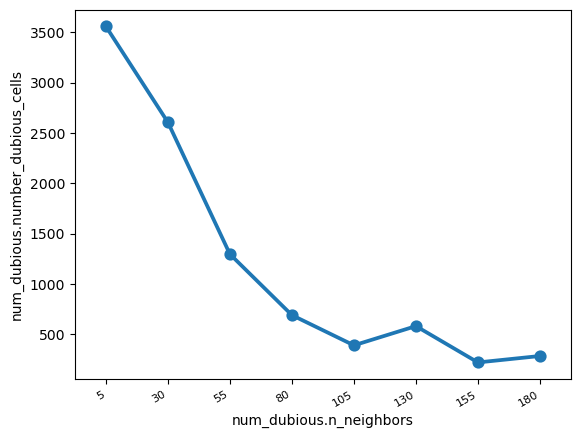

In [8]:
scdeed_analysis = pd.read_csv(Path(PATH_PREFIX) / 'tmp/tasic_scdeed_umap.csv', index_col=0)
sns.pointplot(data=scdeed_analysis[scdeed_analysis['num_dubious.min.dist'] == 0.1], x='num_dubious.n_neighbors', y='num_dubious.number_dubious_cells')
plt.xticks(rotation=30, fontsize=8, ha='right');

In [22]:
tasic_tsne_res_dict = []
X, X_test, y, y_test = load_and_split("cortical", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for perp in np.unique(np.logspace(np.log10(5), np.log10(6000), 10).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"embeddings/cortical_tsne_{perp}_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/cortical/tsne2_{perp}_{s}_ckpts/final.pt",
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2, batchnorm=True)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            train_recon_tsne = np.mean((student_recon.detach().numpy() - X)**2)
            tasic_tsne_res_dict.append({"perplexity": perp, "recon_loss": train_recon_tsne, "split": "Train", "seed": s})

            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            tasic_tsne_res_dict.append({"perplexity": perp, "recon_loss": test_recon_tsne, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {perp} seed {s} due to distillation loss {train_distill}")

loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded par

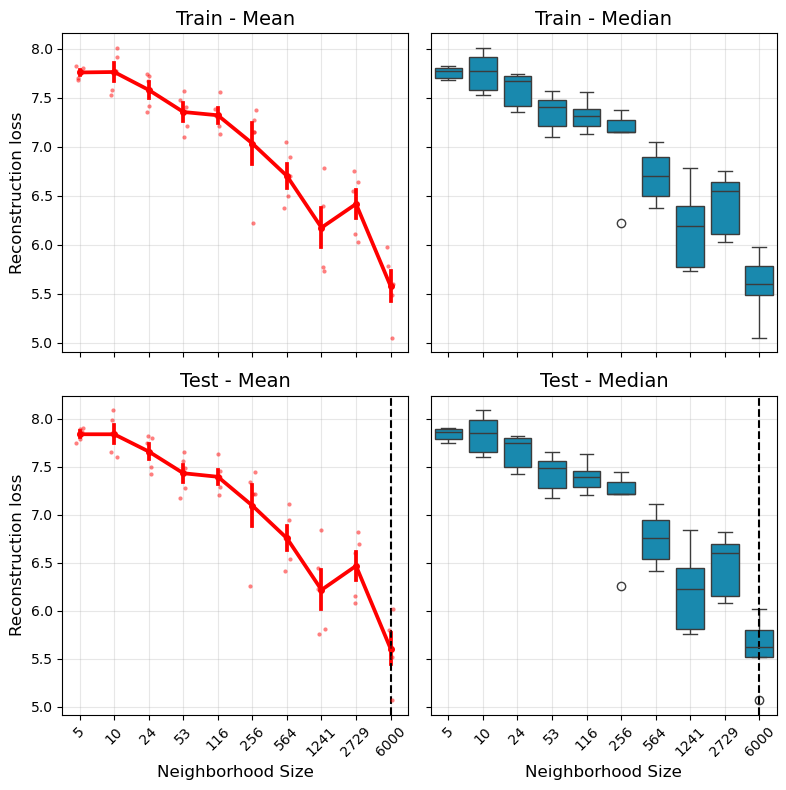

In [23]:
# lr
analysis = pd.DataFrame(tasic_tsne_res_dict)
analysis.sort_values(by='perplexity',inplace=True)
tsne_argmin_mean = analysis[analysis.split == "Test"].groupby('perplexity')['recon_loss'].mean().idxmin()
tsne_argmin_median = analysis[analysis.split == "Test"].groupby('perplexity')['recon_loss'].median().idxmin()
unique_neighbors = sorted(analysis['perplexity'].unique())
pos_mean = unique_neighbors.index(tsne_argmin_mean)
pos_median = unique_neighbors.index(tsne_argmin_median)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), sharey='row', sharex=True)
for i, split in enumerate(['Train', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="perplexity", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="perplexity", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="perplexity", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Neighborhood Size", fontsize=12)
        ax.set_ylabel("Reconstruction loss", fontsize=12)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
    if split == "Test":
        ax_point.axvline(x=pos_mean, ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

plt.tight_layout()
plt.show()


In [24]:
tasic_umap_res_dict = []
X, X_test, y, y_test = load_and_split("cortical", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(2000), 10).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"embeddings/cortical_umap_{n}_0.1_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/cortical/umap2_{n}_0.1_{s}_ckpts/final.pt",
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2, batchnorm = True)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            train_recon = np.mean((student_recon.detach().numpy() - X)**2)
            tasic_umap_res_dict.append({"n_neighbors": n, "recon_loss": train_recon, "split": "Train", "seed": s})

            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            tasic_umap_res_dict.append({"n_neighbors": n, "recon_loss": test_recon, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {n} seed {s} due to distillation loss {train_distill}")

loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded par

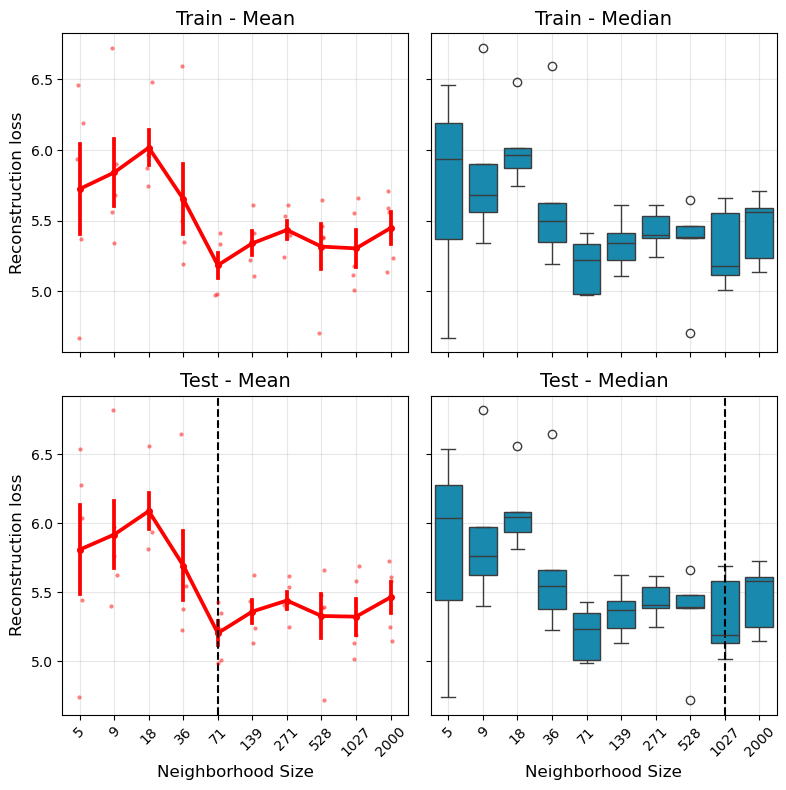

In [25]:
analysis = pd.DataFrame(tasic_umap_res_dict)
analysis.sort_values(by='n_neighbors', inplace=True)
umap_argmin_mean = analysis[analysis.split == "Test"].groupby('n_neighbors')['recon_loss'].mean().idxmin()
umap_argmin_median = analysis[analysis.split == "Test"].groupby('n_neighbors')['recon_loss'].median().idxmin()

unique_neighbors = sorted(analysis['n_neighbors'].unique())
pos_mean = unique_neighbors.index(umap_argmin_mean)
pos_median = unique_neighbors.index(umap_argmin_median)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), sharey='row', sharex=True)

for i, split in enumerate(['Train', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="n_neighbors", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="n_neighbors", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="n_neighbors", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Neighborhood Size", fontsize=12)
        ax.set_ylabel("Reconstruction loss", fontsize=12)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
    if split == "Test":
        ax_point.axvline(x=pos_mean, ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

plt.tight_layout()
plt.show()

In [26]:
tasic_spectral_res_dict = []
X, X_test, y, y_test = load_and_split("cortical", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(200), 15).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"embeddings/cortical_spectral_{n}_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/cortical/spectral2_{n}_{s}_ckpts/final.pt",
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2, batchnorm = True)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            train_recon = np.mean((student_recon.detach().numpy() - X)**2)
            tasic_spectral_res_dict.append({"n_neighbors": n, "recon_loss": train_recon, "split": "Train", "seed": s})

            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            tasic_spectral_res_dict.append({"n_neighbors": n, "recon_loss": test_recon, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {n} seed {s} due to distillation loss {train_distill}")

loaded params: 40 | missing=0 | unexpected=0


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded par

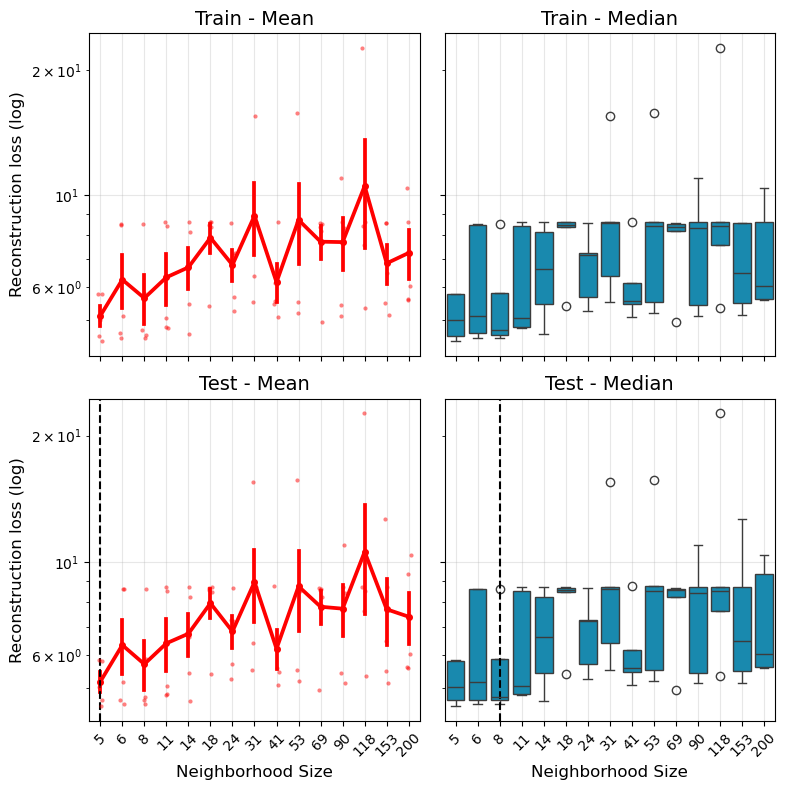

In [27]:
analysis = pd.DataFrame(tasic_spectral_res_dict)
analysis.sort_values(by='n_neighbors',inplace=True)
spectral_argmin_mean = analysis[analysis.split == "Test"].groupby('n_neighbors')['recon_loss'].mean().idxmin()
spectral_argmin_median = analysis[analysis.split == "Test"].groupby('n_neighbors')['recon_loss'].median().idxmin()

unique_neighbors = sorted(analysis['n_neighbors'].unique())
pos_mean = unique_neighbors.index(spectral_argmin_mean)
pos_median = unique_neighbors.index(spectral_argmin_median)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), sharey='row', sharex=True)

for i, split in enumerate(['Train', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="n_neighbors", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="n_neighbors", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="n_neighbors", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Neighborhood Size", fontsize=12)
        ax.set_ylabel("Reconstruction loss (log)", fontsize=12)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
    if split == "Test":
        ax_point.axvline(x=pos_mean, ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

plt.tight_layout()
plt.show()


In [31]:
tasic_pca_res_dict = []
X, X_test, y, y_test = load_and_split("cortical", test_size=0.2, seed=0, labels=True)
for s in range(5):
    student_pca = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/cortical/pca2_{s}_ckpts/final.pt",
                                  input_dim=1000,
                                  hidden_dims=[309, 1792, 1792, 1792],
                                  latent_dim=2, batchnorm=True)
    
    student_recon_pca, student_embed_pca = student_pca(torch.tensor(X, dtype=torch.float32))
    train_recon = np.mean((student_recon_pca.detach().numpy() - X)**2)
    tasic_pca_res_dict.append({"recon_loss": train_recon, "split": "Train", "seed": s})

    x_test_recon, _ = student_pca(torch.tensor(X_test, dtype=torch.float32))
    test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
    tasic_pca_res_dict.append({"recon_loss": test_recon, "split": "Test", "seed": s})

loaded params: 40 | missing=0 | unexpected=0


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


In [32]:
tsne_analysis = pd.DataFrame(tasic_tsne_res_dict)
tsne_analysis = tsne_analysis.loc[(tsne_analysis.split=='Test'),:]
tsne_analysis_agg = tsne_analysis.loc[:, ['perplexity','recon_loss']].groupby('perplexity').agg('mean').reset_index()
umap_analysis = pd.DataFrame(tasic_umap_res_dict)
umap_analysis = umap_analysis.loc[(umap_analysis.split=='Test'), :]
umap_analysis_agg = umap_analysis.loc[:, ['n_neighbors','recon_loss']].groupby('n_neighbors').agg('mean').reset_index()
spectral_analysis = pd.DataFrame(tasic_spectral_res_dict)
spectral_analysis = spectral_analysis.loc[(spectral_analysis.split=='Test'), :]
spectral_analysis_agg = spectral_analysis.loc[:, ['n_neighbors','recon_loss']].groupby('n_neighbors').agg('mean').reset_index()

pca_analysis = pd.DataFrame(tasic_pca_res_dict)
pca_analysis = pca_analysis.loc[(pca_analysis.split=='Test'), :]

tsne_best = tsne_analysis.loc[tsne_analysis.perplexity == tsne_argmin_mean, ['recon_loss', 'seed']]
tsne_best['method'] = f'TSNE(perplexity={tsne_argmin_mean})'
umap_best = umap_analysis.loc[umap_analysis.n_neighbors == umap_argmin_mean, ['recon_loss', 'seed']]
umap_best['method'] = f'UMAP(n_neighbors={umap_argmin_mean})'
spectral_best = spectral_analysis.loc[spectral_analysis.n_neighbors == spectral_argmin_mean, ['recon_loss', 'seed']]
spectral_best['method'] = f'Spectral(n_neighbors={spectral_argmin_mean})'
pca_best = pca_analysis[['recon_loss', 'seed']]
pca_best['method'] = 'PCA'
teachers = pd.concat([tsne_best, umap_best, spectral_best, pca_best])

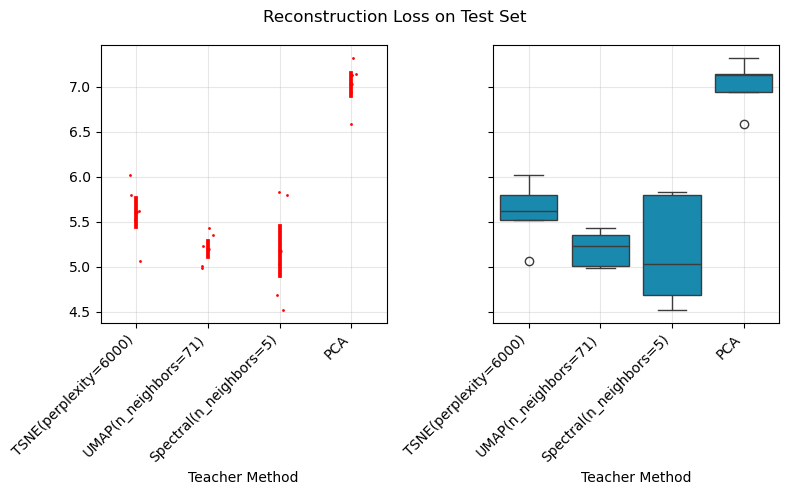

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(8,5), sharey=True)
sns.pointplot(data=teachers, x = 'method', y='recon_loss', linestyles='none', markersize=1, errorbar='se', ax = axes[0], color='red')
sns.stripplot(data=teachers, x = 'method', y='recon_loss', size=2, ax = axes[0], color='red')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel("")
axes[0].set_xlabel("Teacher Method")

sns.boxplot(data=teachers, x = 'method', y='recon_loss', ax = axes[1], color='#0096C7')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel("")

axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel("Teacher Method")
fig.suptitle("Reconstruction Loss on Test Set")

plt.tight_layout()

### Macaque

In [ ]:
macaque_tsne_res_dict = []
X, X_test, y, y_test = load_and_split("macaque", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for perp in np.unique(np.logspace(np.log10(5), np.log10(500), 10).astype(int)):
        student_tsne = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/macaque/tsne2_{perp}_{s}_ckpts/final.pt",
                input_dim=100,
                hidden_dims=[700] * 15,
                latent_dim=2, batchnorm=False)
        student_recon_tsne, student_embed_tsne = student_tsne(torch.tensor(X, dtype=torch.float32))
        train_recon_tsne = np.mean((student_recon_tsne.detach().numpy() - X)**2)
        macaque_tsne_res_dict.append({"perplexity": perp, "recon_loss": train_recon_tsne, "split": "Train", "seed": s})

        x_test_recon, _ = student_tsne(torch.tensor(X_test, dtype=torch.float32))
        test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        macaque_tsne_res_dict.append({"perplexity": perp, "recon_loss": test_recon_tsne, "split": "Test", "seed": s})

loaded params: 64 | missing=0 | unexpected=0


loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded par

In [19]:
analysis.loc[analysis.split == "train", "split"] = "Train"
analysis.loc[analysis.split == "test", "split"] = "Test"

In [20]:
analysis

,perplexity,recon_loss,split,seed
0,5,4.013236,Train,0
1,5,3.645689,Test,0
20,5,4.219494,Train,1
21,5,3.916866,Test,1
60,5,4.047144,Train,3
...,...,...,...,...
38,499,2.259141,Train,1
78,499,1.957560,Train,3
79,499,2.530157,Test,3
98,499,2.206633,Train,4


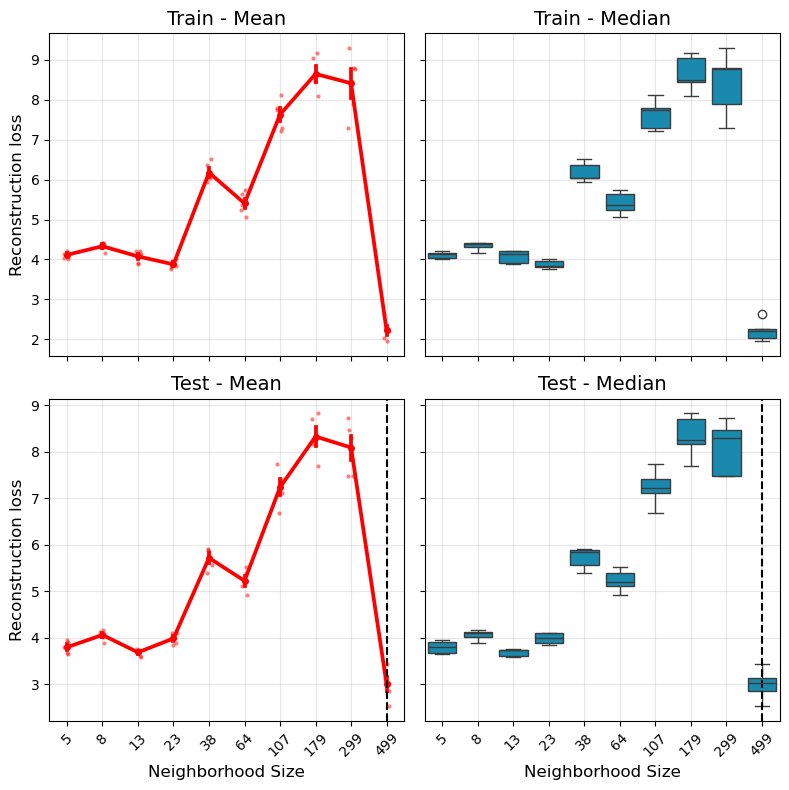

In [21]:
# analysis = pd.DataFrame(macaque_tsne_res_dict)
analysis.sort_values(by='perplexity',inplace=True)
tsne_argmin_mean = analysis[analysis.split == "Test"].groupby('perplexity')['recon_loss'].mean().idxmin()
tsne_argmin_median = analysis[analysis.split == "Test"].groupby('perplexity')['recon_loss'].median().idxmin()
unique_neighbors = sorted(analysis['perplexity'].unique())
pos_mean = unique_neighbors.index(tsne_argmin_mean)
pos_median = unique_neighbors.index(tsne_argmin_median)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), sharey='row', sharex=True)
for i, split in enumerate(['Train', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="perplexity", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="perplexity", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="perplexity", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Neighborhood Size", fontsize=12)
        ax.set_ylabel("Reconstruction loss", fontsize=12)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
    if split == "Test":
        ax_point.axvline(x=pos_mean, ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

plt.tight_layout()
plt.show()

In [23]:
macaque_pca_res_dict = []
X, X_test, y, y_test = load_and_split("macaque", test_size=0.2, seed=0, labels=True)
for s in range(5):
    student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/macaque/pca2_{s}_ckpts/final.pt",
                                  input_dim=100,
                                  hidden_dims=[700] * 15,
                                  latent_dim=2, batchnorm=False)
    
    student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
    train_recon = np.mean((student_recon.detach().numpy() - X)**2)
    macaque_pca_res_dict.append({"recon_loss": train_recon, "split": "Train", "seed": s})

    x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
    test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
    macaque_pca_res_dict.append({"recon_loss": test_recon, "split": "Test", "seed": s})

loaded params: 64 | missing=0 | unexpected=0


loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0
loaded params: 64 | missing=0 | unexpected=0


In [ ]:
tsne_analysis = pd.DataFrame(macaque_tsne_res_dict)
tsne_analysis = tsne_analysis.loc[(tsne_analysis.split=='Test'),:]
tsne_analysis_agg = tsne_analysis.loc[:, ['perplexity','recon_loss']].groupby('perplexity').agg('mean').reset_index()
# umap_analysis = pd.DataFrame(astro_umap_res_dict)
# umap_analysis = umap_analysis.loc[(umap_analysis.split=='Test'), :]
# umap_analysis_agg = umap_analysis.loc[:, ['n_neighbors','recon_loss']].groupby('n_neighbors').agg('mean').reset_index()
# spectral_analysis = pd.DataFrame(astro_spectral_res_dict)
# spectral_analysis = spectral_analysis.loc[(spectral_analysis.split=='Test'), :]
# spectral_analysis_agg = spectral_analysis.loc[:, ['n_neighbors','recon_loss']].groupby('n_neighbors').agg('mean').reset_index()

pca_analysis = pd.DataFrame(macaque_pca_res_dict)
pca_analysis = pca_analysis.loc[(pca_analysis.split=='Test'), :]

tsne_best = tsne_analysis.loc[tsne_analysis.perplexity == tsne_argmin_mean, ['recon_loss', 'seed']]
tsne_best['method'] = f'TSNE(perplexity={tsne_argmin_mean})'
# umap_best = umap_analysis.loc[umap_analysis.n_neighbors == umap_argmin_mean, ['recon_loss', 'seed']]
# umap_best['method'] = f'UMAP(n_neighbors={umap_argmin_mean})'
# spectral_best = spectral_analysis.loc[spectral_analysis.n_neighbors == spectral_argmin_mean, ['recon_loss', 'seed']]
# spectral_best['method'] = f'Spectral(n_neighbors={spectral_argmin_mean})'
pca_best = pca_analysis[['recon_loss', 'seed']]
pca_best['method'] = 'PCA'
teachers = pd.concat([tsne_best, pca_best])

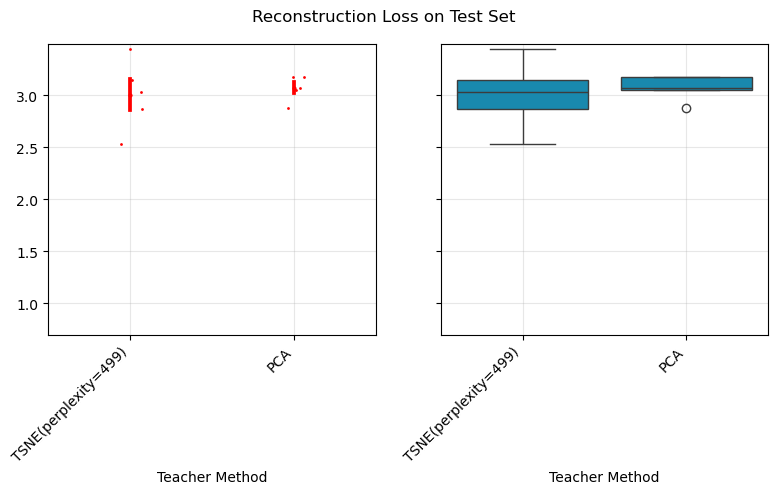

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(8,5), sharey=True)
sns.pointplot(data=teachers, x = 'method', y='recon_loss', linestyles='none', markersize=1, errorbar='se', ax = axes[0], color='red')
sns.stripplot(data=teachers, x = 'method', y='recon_loss', size=2, ax = axes[0], color='red')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel("")
axes[0].set_xlabel("Teacher Method")
axes[0].set_ylim(bottom=0.7)

sns.boxplot(data=teachers, x = 'method', y='recon_loss', ax = axes[1], color='#0096C7')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel("")

axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel("Teacher Method")
fig.suptitle("Reconstruction Loss on Test Set")

plt.tight_layout()

### Astro

In [72]:
astro_tsne_res_dict = []
X, X_test, y, y_test = load_and_split("astro", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for perp in np.unique(np.logspace(np.log10(3), np.log10(500), 15).astype(int)):
        if perp == 38: continue
        teacher_embed = np.load(Path(PATH_PREFIX) / f"embeddings/astro_tsne_{perp}_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/astro/tsne2_{perp}_{s}_ckpts/final.pt",
                input_dim=19,
                hidden_dims=[700] * 15,
                latent_dim=2, batchnorm=False)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            train_recon = np.mean((student_recon.detach().numpy() - X)**2)
            astro_tsne_res_dict.append({"perplexity": perp, "recon_loss": train_recon, "split": "Train", "seed": s})

            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            astro_tsne_res_dict.append({"perplexity": perp, "recon_loss": test_recon, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {perp} seed {s} due to distillation loss {train_distill}")

loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded par

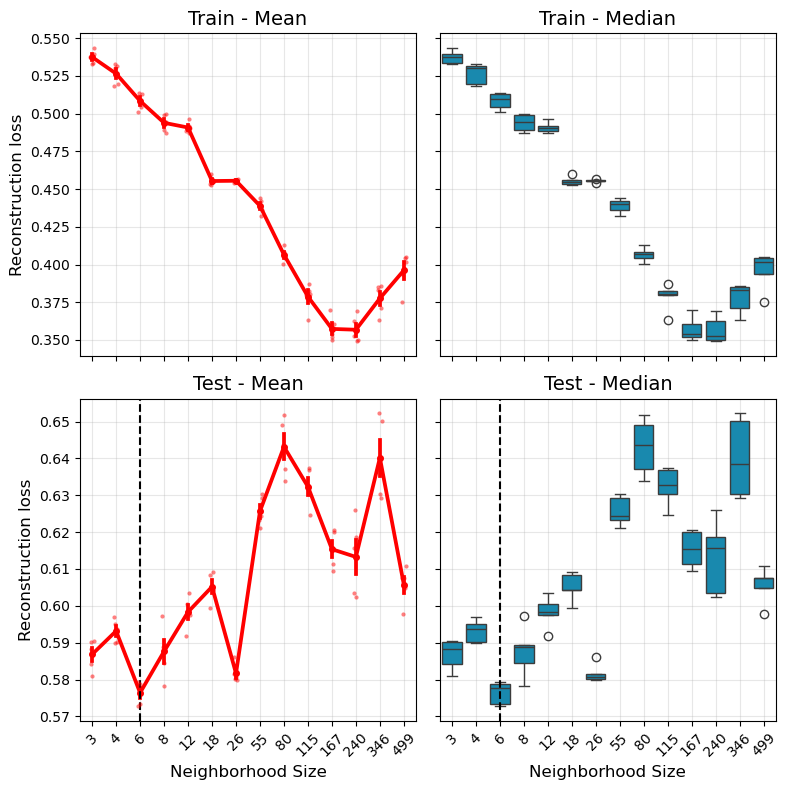

In [73]:
analysis = pd.DataFrame(astro_tsne_res_dict)
analysis.sort_values(by='perplexity',inplace=True)
tsne_argmin_mean = analysis[analysis.split == "Test"].groupby('perplexity')['recon_loss'].mean().idxmin()
tsne_argmin_median = analysis[analysis.split == "Test"].groupby('perplexity')['recon_loss'].median().idxmin()
unique_neighbors = sorted(analysis['perplexity'].unique())
pos_mean = unique_neighbors.index(tsne_argmin_mean)
pos_median = unique_neighbors.index(tsne_argmin_median)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), sharey='row', sharex=True)
for i, split in enumerate(['Train', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="perplexity", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="perplexity", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="perplexity", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Neighborhood Size", fontsize=12)
        ax.set_ylabel("Reconstruction loss", fontsize=12)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
    if split == "Test":
        ax_point.axvline(x=pos_mean, ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

plt.tight_layout()
plt.show()

In [75]:
astro_umap_res_dict = []
X, X_test, y, y_test = load_and_split("astro", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"embeddings/astro_umap_{n}_0.1_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/astro/umap2_{n}_0.1_{s}_ckpts/final.pt",
                input_dim=19,
                hidden_dims=[700]*15,
                latent_dim=2, batchnorm=False)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            train_recon = np.mean((student_recon.detach().numpy() - X)**2)
            astro_umap_res_dict.append({"n_neighbors": n, "recon_loss": train_recon, "split": "Train", "seed": s})

            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            astro_umap_res_dict.append({"n_neighbors": n, "recon_loss": test_recon, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {n} seed {s} due to distillation loss {train_distill}")

loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded par

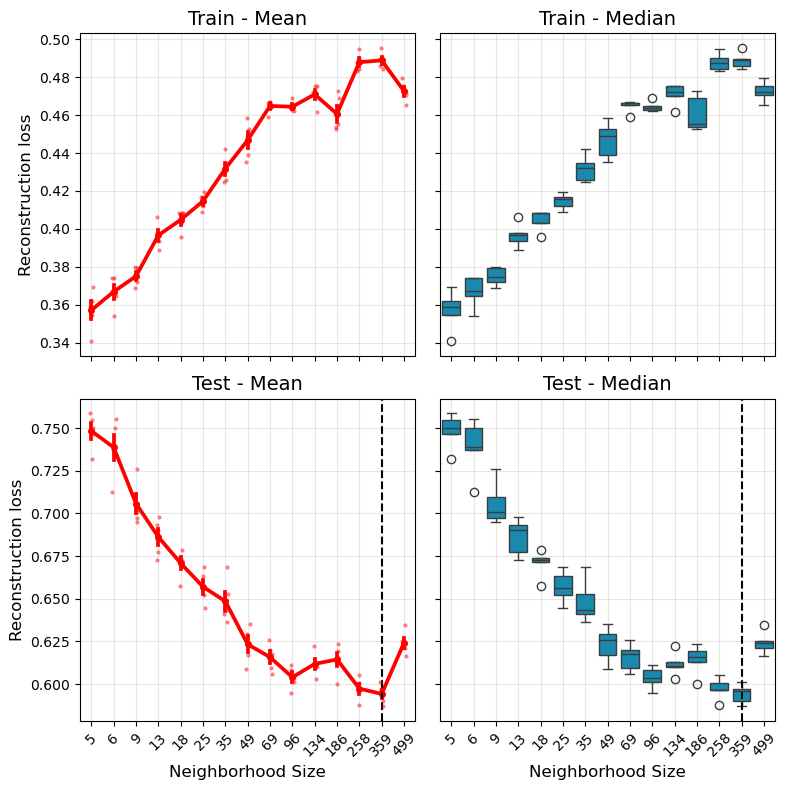

In [76]:
analysis = pd.DataFrame(astro_umap_res_dict)
analysis.sort_values(by='n_neighbors', inplace=True)
umap_argmin_mean = analysis[analysis.split == "Test"].groupby('n_neighbors')['recon_loss'].mean().idxmin()
umap_argmin_median = analysis[analysis.split == "Test"].groupby('n_neighbors')['recon_loss'].median().idxmin()

unique_neighbors = sorted(analysis['n_neighbors'].unique())
pos_mean = unique_neighbors.index(umap_argmin_mean)
pos_median = unique_neighbors.index(umap_argmin_median)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), sharey='row', sharex=True)

for i, split in enumerate(['Train', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="n_neighbors", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="n_neighbors", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="n_neighbors", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Neighborhood Size", fontsize=12)
        ax.set_ylabel("Reconstruction loss", fontsize=12)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
    if split == "Test":
        ax_point.axvline(x=pos_mean, ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

plt.tight_layout()
plt.show()

In [77]:
astro_spectral_res_dict = []
X, X_test, y, y_test = load_and_split("astro", test_size=0.2, seed=0, labels=True)
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"embeddings/astro_spectral_{n}_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/astro/spectral2_{n}_{s}_ckpts/final.pt",
                input_dim=19,
                hidden_dims=[700]*15,
                latent_dim=2, batchnorm=False)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            train_recon = np.mean((student_recon.detach().numpy() - X)**2)
            astro_spectral_res_dict.append({"n_neighbors": n, "recon_loss": train_recon, "split": "Train", "seed": s})

            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            astro_spectral_res_dict.append({"n_neighbors": n, "recon_loss": test_recon, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {n} seed {s} due to distillation loss {train_distill}")

loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded par

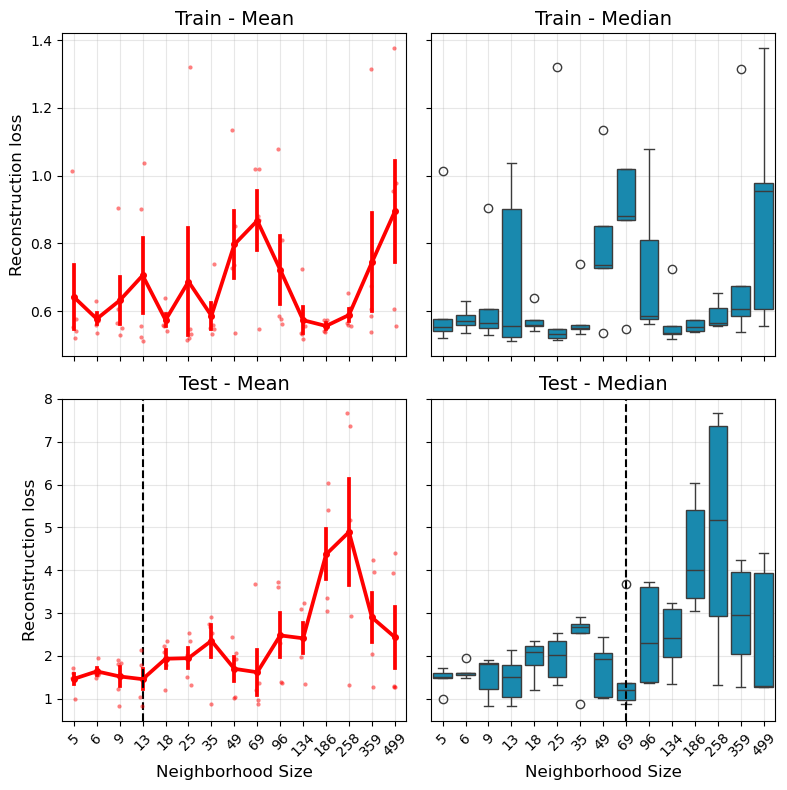

In [81]:
analysis = pd.DataFrame(astro_spectral_res_dict)
analysis.sort_values(by='n_neighbors',inplace=True)
spectral_argmin_mean = analysis[analysis.split == "Test"].groupby('n_neighbors')['recon_loss'].mean().idxmin()
spectral_argmin_median = analysis[analysis.split == "Test"].groupby('n_neighbors')['recon_loss'].median().idxmin()

unique_neighbors = sorted(analysis['n_neighbors'].unique())
pos_mean = unique_neighbors.index(spectral_argmin_mean)
pos_median = unique_neighbors.index(spectral_argmin_median)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), sharey='row', sharex=True)

for i, split in enumerate(['Train', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="n_neighbors", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="n_neighbors", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="n_neighbors", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        # if split == "Test": ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Neighborhood Size", fontsize=12)
        ax.set_ylabel("Reconstruction loss", fontsize=12)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
    if split == "Test":
        ax_point.axvline(x=pos_mean, ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

plt.tight_layout()
plt.show()


In [79]:
astro_pca_res_dict = []
X, X_test, y, y_test = load_and_split("astro", test_size=0.2, seed=0, labels=True)
for s in range(5):
    student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/astro/pca2_{s}_ckpts/final.pt",
                                  input_dim=19,
                                  hidden_dims=[700] * 15,
                                  latent_dim=2, batchnorm=False)
    
    student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
    train_recon = np.mean((student_recon.detach().numpy() - X)**2)
    astro_pca_res_dict.append({"recon_loss": train_recon, "split": "Train", "seed": s})

    x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
    test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
    astro_pca_res_dict.append({"recon_loss": test_recon, "split": "Test", "seed": s})

loaded params: 69 | missing=0 | unexpected=0


loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0
loaded params: 69 | missing=0 | unexpected=0


In [80]:
tsne_analysis = pd.DataFrame(astro_tsne_res_dict)
tsne_analysis = tsne_analysis.loc[(tsne_analysis.split=='Test'),:]
tsne_analysis_agg = tsne_analysis.loc[:, ['perplexity','recon_loss']].groupby('perplexity').agg('mean').reset_index()
umap_analysis = pd.DataFrame(astro_umap_res_dict)
umap_analysis = umap_analysis.loc[(umap_analysis.split=='Test'), :]
umap_analysis_agg = umap_analysis.loc[:, ['n_neighbors','recon_loss']].groupby('n_neighbors').agg('mean').reset_index()
spectral_analysis = pd.DataFrame(astro_spectral_res_dict)
spectral_analysis = spectral_analysis.loc[(spectral_analysis.split=='Test'), :]
spectral_analysis_agg = spectral_analysis.loc[:, ['n_neighbors','recon_loss']].groupby('n_neighbors').agg('mean').reset_index()

pca_analysis = pd.DataFrame(astro_pca_res_dict)
pca_analysis = pca_analysis.loc[(pca_analysis.split=='Test'), :]

tsne_best = tsne_analysis.loc[tsne_analysis.perplexity == tsne_argmin_mean, ['recon_loss', 'seed']]
tsne_best['method'] = f'TSNE(perplexity={tsne_argmin_mean})'
umap_best = umap_analysis.loc[umap_analysis.n_neighbors == umap_argmin_mean, ['recon_loss', 'seed']]
umap_best['method'] = f'UMAP(n_neighbors={umap_argmin_mean})'
spectral_best = spectral_analysis.loc[spectral_analysis.n_neighbors == spectral_argmin_mean, ['recon_loss', 'seed']]
spectral_best['method'] = f'Spectral(n_neighbors={spectral_argmin_mean})'
pca_best = pca_analysis[['recon_loss', 'seed']]
pca_best['method'] = 'PCA'
teachers = pd.concat([tsne_best, umap_best, spectral_best, pca_best])

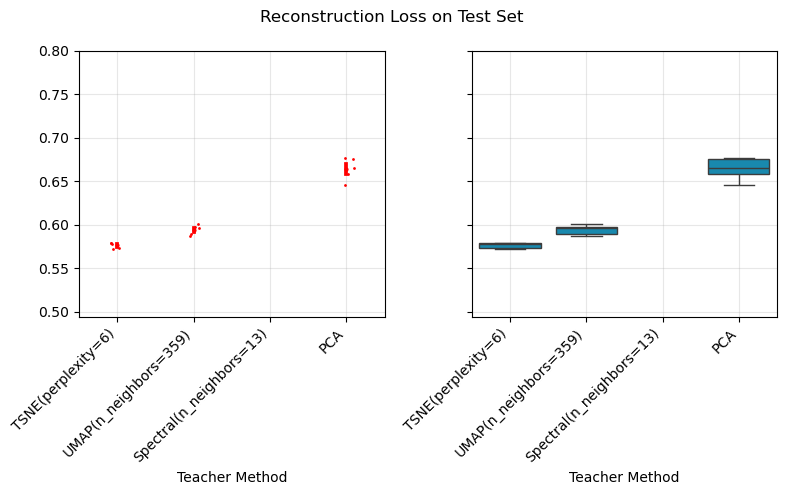

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8,5), sharey=True)
sns.pointplot(data=teachers, x = 'method', y='recon_loss', linestyles='none', markersize=1, errorbar='se', ax = axes[0], color='red')
sns.stripplot(data=teachers, x = 'method', y='recon_loss', size=2, ax = axes[0], color='red')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel("")
axes[0].set_xlabel("Teacher Method")
axes[0].set_ylim(top=0.8)

sns.boxplot(data=teachers, x = 'method', y='recon_loss', ax = axes[1], color='#0096C7')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel("")

axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel("Teacher Method")
fig.suptitle("Reconstruction Loss on Test Set")

plt.tight_layout()

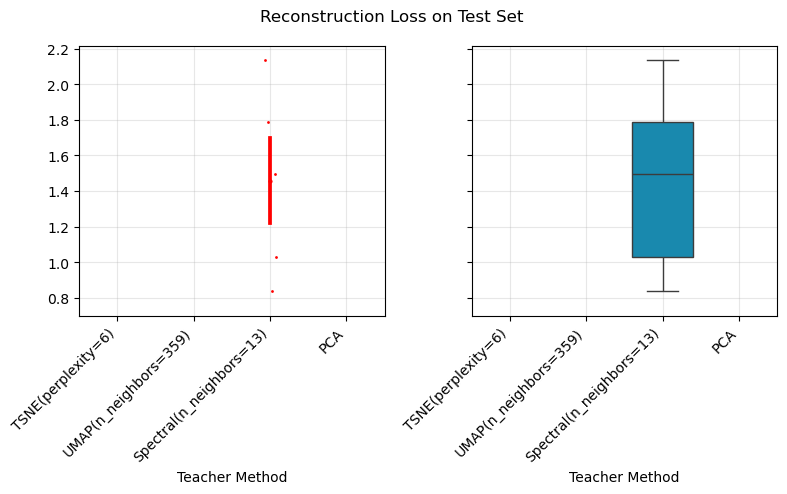

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(8,5), sharey=True)
sns.pointplot(data=teachers, x = 'method', y='recon_loss', linestyles='none', markersize=1, errorbar='se', ax = axes[0], color='red')
sns.stripplot(data=teachers, x = 'method', y='recon_loss', size=2, ax = axes[0], color='red')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel("")
axes[0].set_xlabel("Teacher Method")
axes[0].set_ylim(bottom=0.7)

sns.boxplot(data=teachers, x = 'method', y='recon_loss', ax = axes[1], color='#0096C7')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel("")

axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel("Teacher Method")
fig.suptitle("Reconstruction Loss on Test Set")

plt.tight_layout()